In [77]:
import pandas as pd 
import numpy as np

df = pd.read_csv('/Users/Deep/Downloads/StrokePrediction/StrokePrediction_ISAN567_ML/healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [78]:
df_copy = df.copy()

In [79]:
df_copy.drop('id', axis=1, inplace=True)

In [80]:
df_copy['stroke'].unique()

array([1, 0])

In [81]:
df_copy.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [82]:
df_copy.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [83]:
df_copy['stroke'].where(df_copy['stroke']==1).value_counts() 

stroke
1.0    249
Name: count, dtype: int64

In [84]:

bmi_null_data = df_copy[df_copy['bmi'].isnull()]
bmi_null_data['stroke'].where(bmi_null_data['stroke'] == 1).value_counts()
#bmi_null_data.to_csv('bmi_null_data.csv', index=False)



stroke
1.0    40
Name: count, dtype: int64

#Imputing the missing BMI values since BMI is missing for 40 people who got Stroke out of 249 total.. 

In [85]:
# Used grouped median imputation to fill missing BMI
#age bins and labels for filling missing BMI values
bins = [0, 25, 45, 65, 85, 100]
labels = ['young', 'early_adult', 'middle_aged', 'senior', 'elderly']

df_copy['age_group'] = pd.cut(df_copy['age'], bins=bins, labels=labels)

# Fill missing BMI with median of each age group
df_copy['bmi'] = df_copy.groupby('age_group', observed=True)['bmi'].transform(
    lambda x: x.fillna(x.median())
)

# Drop helper column
df_copy.drop('age_group', axis=1, inplace=True)

# Verify
print(df_copy['bmi'].isnull().sum())  

0


In [86]:
df_copy.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.870724,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.717508,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.300000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [87]:
df_copy.info()


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 594.7 KB


In [88]:
feature_columns = df_copy.columns
print(feature_columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [89]:
#gender ever_married, work_type, residence_type,smoking_status are categorical 

print(df_copy['gender'].unique())
print(df_copy['ever_married'].unique())
print(df_copy['work_type'].unique())
print(df_copy['Residence_type'].unique())
print(df_copy['smoking_status'].unique())

<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
<ArrowStringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
<ArrowStringArray>
['Urban', 'Rural']
Length: 2, dtype: str
<ArrowStringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


In [90]:
# #label encoding for categorical variables 
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
# for col in categorical_cols:
#     df_copy[col] = le.fit_transform(df_copy[col])               

# df_copy.head()
# df_copy.to_csv('stroke_prediction_preprocessed.csv', index=False)   

In [108]:
df_copy.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [91]:
df_copy['ever_married'] = df_copy['ever_married'].map({'No': 0, 'Yes': 1}).astype(int)

In [92]:
cat_cols = ['gender','work_type','Residence_type','smoking_status']

def preprocess_data(df):
    df_processed = df.copy()
    # One-hot encode categorical variables
    df_processed = pd.get_dummies(df_processed, columns=cat_cols, drop_first=True)
    
    bool_cols = df_processed.select_dtypes(include='bool').columns
    df_processed[bool_cols] = df_processed[bool_cols].astype(int)
    return df_processed

df_preprocessed = preprocess_data(df_copy)
df_preprocessed.head()



,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,228.69,36.6,1,1,0,0,1,0,0,1,1,0,0
1,61.0,0,0,1,202.21,30.3,1,0,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,105.92,32.5,1,1,0,0,1,0,0,0,0,1,0
3,49.0,0,0,1,171.23,34.4,1,0,0,0,1,0,0,1,0,0,1
4,79.0,1,0,1,174.12,24.0,1,0,0,0,0,1,0,0,0,1,0


In [107]:
num_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'gender_Other', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


/var/folders/jd/746wbsm133x23cvkw2qlxzmh0000gp/T/ipykernel_31137/99920668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df_preprocessed, palette='Set2')


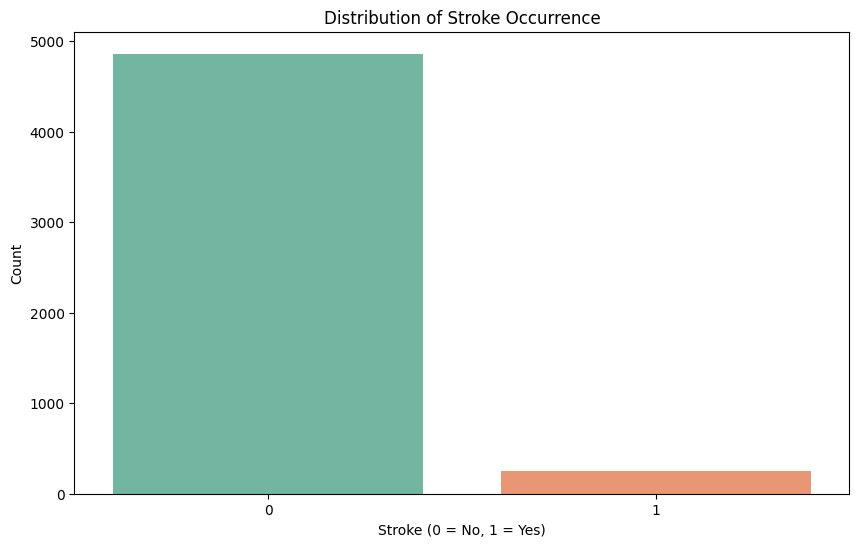

In [93]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(10,6))
sns.countplot(x='stroke', data=df_preprocessed, palette='Set2')
plt.title('Distribution of Stroke Occurrence')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

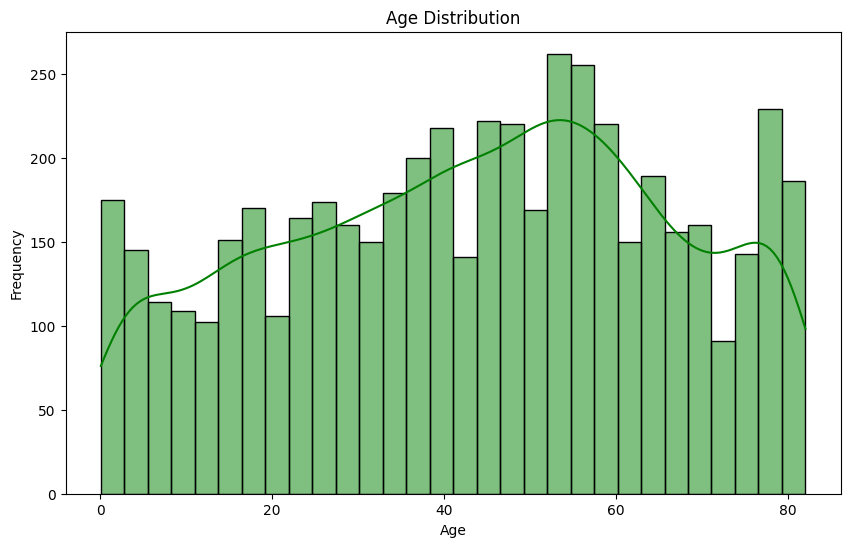

In [94]:
plt.figure(figsize=(10,6))
sns.histplot(df_preprocessed['age'], bins=30, kde=True,color='green')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

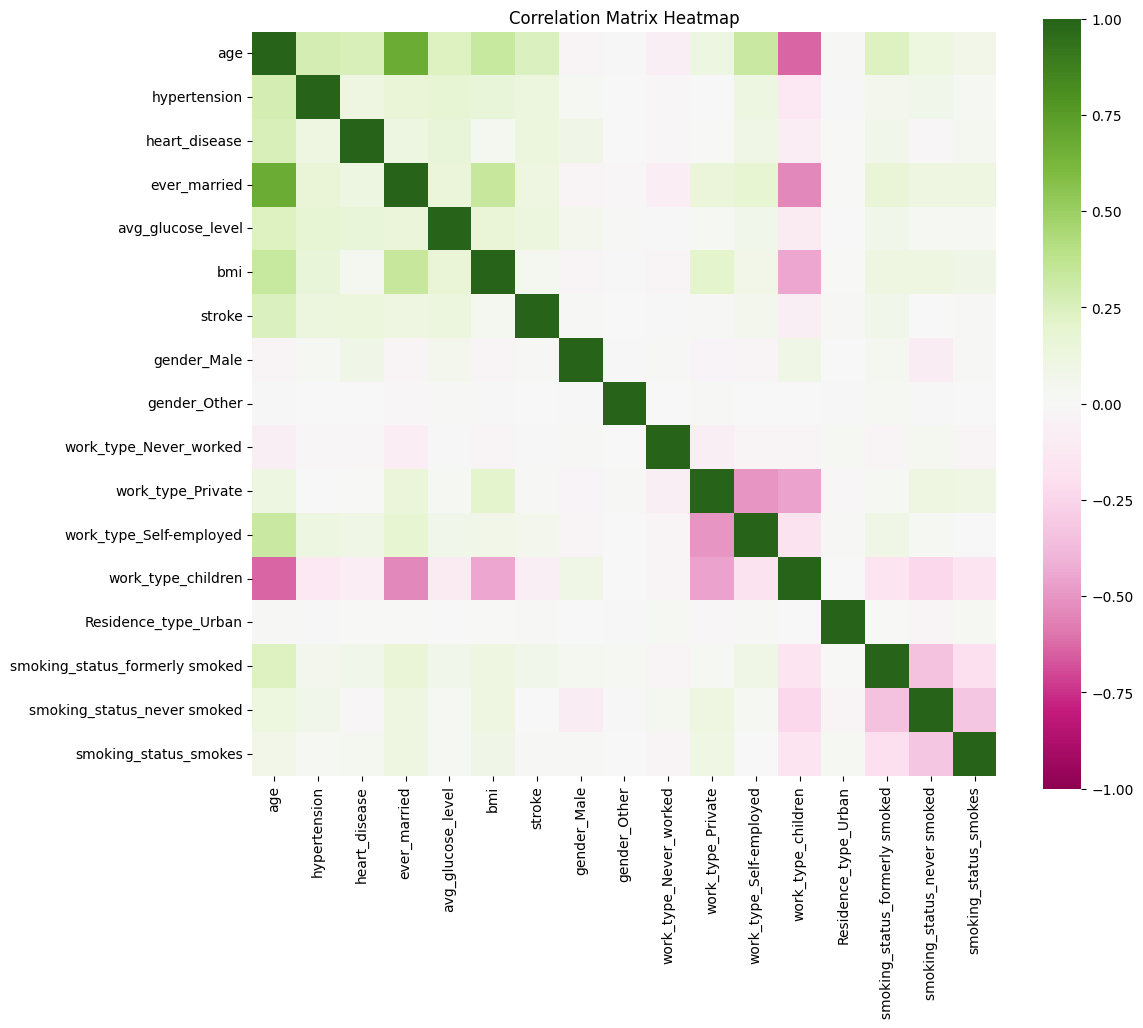

In [95]:
num_df = df_preprocessed.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
corr = num_df.corr()  # Pearson correlations
sns.heatmap(
    corr,
    cmap='PiYG',
    vmin=-1, vmax=1,
    center=0,
    annot=False,   # change to True if you want numbers
    square=True
)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [96]:

feature_cols = [c for c in df_preprocessed.columns if c != 'stroke']

X = df_preprocessed[feature_cols].values
y = df_preprocessed['stroke'].values

In [97]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score ,balanced_accuracy_score,precision_score ,roc_auc_score,f1_score

In [ ]:
from sklearn.preprocessing import LabelEncoder
#sampling the training data
#Oversampled (SMOTE on scaled data)

smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)




scaler_org = StandardScaler()
X_train_scaled_org = scaler_org.fit_transform(X_train)
X_test_scaled_org = scaler_org.transform(X_test)

#scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_over)
X_test_scaled = scaler.transform(X_test)





In [100]:
scaled_models ={
    'lr_model' : LogisticRegression(class_weight='balanced'),
    'knn_model' : KNeighborsClassifier(n_neighbors=4),
    'discriminant_model' : LinearDiscriminantAnalysis(),
    'svm_model' : SVC(kernel='rbf', class_weight='balanced'),

    #************************************* Added Bagging and Neural Network  *************************************************************
    'bagging' : BaggingClassifier(n_estimators=100,random_state=42),
    'neural_network': MLPClassifier(hidden_layer_sizes=(100,50),max_iter=500,random_state=42)
}
tree_models ={
    'dt_model' : DecisionTreeClassifier(random_state=42),
    'bayes_model' : GaussianNB(),
    'dt_model_pruned' : DecisionTreeClassifier(random_state=42, max_depth=5),

        #************************************* Added Boosting (AdaBoost and GradingBoost) and Random Forest  *************************************************************
    'random_forest': RandomForestClassifier(n_estimators=100,random_state=42),
    'adaboost': AdaBoostClassifier(n_estimators=100,random_state=42),
    'gradient_boosting': GradientBoostingClassifier(n_estimators=100,random_state=42)
}


In [101]:
data_versions_scaled = {
    'Scaled'      : (X_train_scaled_org, y_train),
    'Oversampled' : (X_train_scaled,   y_train_over),
}

data_versions_tree = {     
    
    'Oversampled' : (X_train_over,  y_train_over),
}

In [102]:
def evaluate(y_true, y_pred, y_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn)   # recall for stroke=1
    specificity = tn / (tn + fp)   # recall for no-stroke=0

    results = {
        'accuracy'          : round(accuracy_score(y_true, y_pred) * 100, 2),
        'sensitivity'       : round(sensitivity * 100, 2),
        'specificity'       : round(specificity * 100, 2),
        'precision'         : round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'f1_score'         : round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
        'balanced_accuracy' : round(balanced_accuracy_score(y_true, y_pred) * 100, 2),
        'roc_auc'           : round(roc_auc_score(y_true, y_proba) * 100, 2) if y_proba is not None else None,
    }

    return pd.DataFrame([results])

In [103]:

all_results    = []
summary_results = []

# ── Scaled Models (LR, KNN, DNN, SVM etc.) ──────────────────────────────────
for name, model in scaled_models.items():
    for d_name, (X_tr, y_tr) in data_versions_scaled.items():

        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1] \
                  if hasattr(model, 'predict_proba') else None

        # evaluate returns a one-row DataFrame
        df_result = evaluate(y_test, y_pred, y_proba=y_proba)
        df_result['model']        = name
        df_result['data_version'] = d_name
        all_results.append(df_result)

        #
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        row = df_result.iloc[0]
        summary_results.append({
            'model'            :  name,
            'version'          : d_name,
            'accuracy'         : row['accuracy'],
            'sensitivity'      : row['sensitivity'],
            'specificity'      : row['specificity'],
            'precision'        : row['precision'],
            'f1_score'         : row['f1_score'],
            'balanced_accuracy': row['balanced_accuracy'],
            'roc_auc'          : row['roc_auc'],
        })

# ── Tree-based Models (RF, GBM, DT) ────────────────────────────────────
for name, model in tree_models.items():
    for s_name, (X_tr, y_tr) in data_versions_tree.items():
        

        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] \
                  if hasattr(model, 'predict_proba') else None

        df_result = evaluate(y_test, y_pred, y_proba=y_proba)
        df_result['model']        = name
        df_result['data_version'] = s_name
        all_results.append(df_result)

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        row = df_result.iloc[0]
        summary_results.append({
            'model'            : name,
            'version'          : s_name,
            'accuracy'         : row['accuracy'],
            'sensitivity'      : row['sensitivity'],
            'specificity'      : row['specificity'],
            'precision'        : row['precision'],
            'f1_score'         : row['f1_score'],
            'balanced_accuracy': row['balanced_accuracy'],
            'roc_auc'          : row['roc_auc'],
        })

# ── Combine & Export ─────────────────────────────────────────────────────────
final_result_metric_df = pd.concat(all_results, ignore_index=True)
print(final_result_metric_df.to_string(index=False))

final_summary_df = pd.DataFrame(summary_results)
print(final_summary_df.to_string(index=False))

# export both sheets to one Excel file
with pd.ExcelWriter('FinalMetrics.xlsx') as writer:
    final_result_metric_df.to_excel(writer, sheet_name='DetailedMetrics', index=False)
    final_summary_df.to_excel(writer, sheet_name='Summary', index=False)

 accuracy  sensitivity  specificity  precision  f1_score  balanced_accuracy roc_auc              model data_version
    86.30         66.0        87.35      21.15     32.04              76.67   84.48           lr_model       Scaled
    75.15         80.0        74.90      14.08     23.95              77.45   84.27           lr_model  Oversampled
    95.30          4.0       100.00     100.00      7.69              52.00   58.09          knn_model       Scaled
    88.06         14.0        91.87       8.14     10.29              52.94   63.04          knn_model  Oversampled
    95.11          2.0        99.90      50.00      3.85              50.95   82.34 discriminant_model       Scaled
    73.97         82.0        73.56      13.76     23.56              77.78   84.53 discriminant_model  Oversampled
    87.57         46.0        89.71      18.70     26.59              67.86    None          svm_model       Scaled
    91.49         22.0        95.06      18.64     20.18              58

In [104]:
print(scaled_models.keys())
print(tree_models.keys())

dict_keys(['lr_model', 'knn_model', 'discriminant_model', 'svm_model', 'bagging', 'neural_network'])
dict_keys(['dt_model', 'bayes_model', 'dt_model_pruned', 'random_forest', 'adaboost', 'gradient_boosting'])


************************v\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
**********************************************************************************************

In [105]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.compose import ColumnTransformer

# num_cols = ['age', 'avg_glucose_level', 'bmi']
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols)
#     ], remainder='passthrough'
# )

# final_model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', LogisticRegression(class_weight='balanced'))
# ])


# final_model.fit(X_train, y_train)

In [106]:
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.over_sampling import SMOTE
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# import os 
# import json
# import pickle

# os.makedirs('model', exist_ok=True)

# lr_pipeline = ImbPipeline([
#     ('smote',  SMOTE(random_state=42)),       # oversamples during fit() only
#     ('scaler', StandardScaler()),
#     ('model',  LogisticRegression(class_weight='balanced', random_state=42))
# ])
# # Use the OVERSAMPLED scaled version — same as your loop used

# X_tr, y_tr = data_versions_scaled['Oversampled']

# # Refit pipeline on correct data
# lr_pipeline.fit(X_tr, y_tr)

# # Verify
# print(f"Scaler now expects: {lr_pipeline.named_steps['scaler'].n_features_in_} features")

# # Save again
# with open('model/lr_pipeline.pkl', 'wb') as f:
#     pickle.dump(lr_pipeline, f)

# # Save correct feature cols
# import json
# feature_cols = [c for c in X.columns]  # exclude nothing — X shouldn't have 'stroke'
# print(f"Saving {len(feature_cols)} cols: {feature_cols}")

# with open('model/feature_cols.json', 'w') as f:
#     json.dump(feature_cols, f)
# cols = list(lr_pipeline.named_steps['scaler'].feature_names_in_)
# print(f"Saving {len(cols)} columns: {cols}")

# print("✅ Saved correctly")

In [ ]:
import pickle

with open('models_pipeline.pkl', 'wb') as f:
    pickle.dump({
        'scaled_models'         : scaled_models,
        'tree_models'           : tree_models,
        'data_versions_scaled'  : data_versions_scaled,
        'data_versions_tree'    : data_versions_tree,
        'X_test_scaled'         : X_test_scaled,
        'X_test'                : X_test,
        'y_test'                : y_test,
    }, f)

print("Saved to models_pipeline.pkl")

In [ ]:
with open('models_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

scaled_models          = pipeline['scaled_models']
tree_models            = pipeline['tree_models']
data_versions_scaled   = pipeline['data_versions_scaled']
data_versions_tree     = pipeline['data_versions_tree']
X_test_scaled          = pipeline['X_test_scaled']
X_test                 = pipeline['X_test']
y_test                 = pipeline['y_test']